# notes

description:
    - Load the UV scan csv data in UV_data/file.csv, clean headers, parse numeric columns, and graph trace (abs vs wavelength nm) 
    - Optionally plot multiple traces against each other 
    - Optionally normalize those traces to any column of the dataset

requirements:
    pandas, matplotlib

# imports

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels
from pathlib import Path

# file

In [25]:
csvfiles = ["20260323 TigE UV scan.csv", "20260402 TigE UV scan.csv"]
# print(f"Current csvfile: {csvfile}")
DATA_DIR = Path(csvfiles[0]).resolve().parent 
# print(f"Data directory: {DATA_DIR}")
CSV_FILES = [DATA_DIR / file for file in csvfiles]
# print(f"Reading data from: {CSV_FILES}")

# read raw csv


In [26]:
# 1st row has sample info header; 2nd row has data info header; 3rd+ row is data 

# choose suffixes for each csv (leave blank for nothing)
separator = "_"
suffixes = ["as-isolated", "postRCN"]

uv_scan_df = pd.DataFrame()  # initialize empty df to concatenate into
for CSV_FILE, suffix in zip(CSV_FILES, suffixes):
    raw_headers = pd.read_csv(CSV_FILE, nrows=2, header=None)
    sample_header = raw_headers.iloc[0].ffill()  # forward fill sample header row 
    data_header = raw_headers.iloc[1]
    header = sample_header.astype(str) + separator + data_header.astype(str) + separator + suffix
    valid_mask = ~header.str.contains('nan', na=False)      # filter NaN columns
    header = header[valid_mask]
    # print(header)

    # read in data rows 
    uv_scan_raw = pd.read_csv(
        CSV_FILE,
        sep=",",
        skiprows=2,
        header=None,  # we already dealt with this
        engine="python",
        encoding="utf-8",
        na_values=["", '""'],
    )
    current_uv_scan_df = uv_scan_raw.apply(pd.to_numeric, errors="coerce")    # convert to numeric
    current_uv_scan_df = current_uv_scan_df.iloc[:, valid_mask.values]  # filter data columns to match valid headers
    current_uv_scan_df.columns = header    # add headers back in 
    uv_scan_df = pd.concat([uv_scan_df, current_uv_scan_df], axis=1)

uv_scan_df = uv_scan_df.dropna(axis=1, how='all')  # remove NaN columns
# print(uv_scan_df.head())

print("Headers to copy into column selection:")
for col in uv_scan_df.columns: print(col)

Headers to copy into column selection:
Baseline 100%T_Wavelength (nm)_as-isolated
Baseline 100%T_Abs_as-isolated
TigE 200_Wavelength (nm)_as-isolated
TigE 200_Abs_as-isolated
Baseline 100%T_Wavelength (nm)_postRCN
Baseline 100%T_Abs_postRCN
TigE_200x_Wavelength (nm)_postRCN
TigE_200x_Abs_postRCN
TigE_100x_Wavelength (nm)_postRCN
TigE_100x_Abs_postRCN


# select columns to plot

In [27]:
## select baseline wavelength, baseline abs, and enzyme abs columns 
cols_to_choose = ['Baseline 100%T_Wavelength (nm)_as-isolated',  # wavelengths for x axis 
                    'Baseline 100%T_Abs_as-isolated',  # baseline absorbance values 
                    'TigE 200_Abs_as-isolated',
                    'TigE_100x_Abs_postRCN'    # enzyme(s) of interest - choose the .Abs columns 
                  ]
uv_scan_df = uv_scan_df[cols_to_choose]

# print("sample data:")
# print(uv_scan_df.head())

print("copy+paste dictionary into legend section to edit legend labels\n")
print("label_map = {")
for col in uv_scan_df.columns[1:]:
    print(f"    '{col}': '{col}',")
print("}")

copy+paste dictionary into legend section to edit legend labels

label_map = {
    'Baseline 100%T_Abs_as-isolated': 'Baseline 100%T_Abs_as-isolated',
    'TigE 200_Abs_as-isolated': 'TigE 200_Abs_as-isolated',
    'TigE_100x_Abs_postRCN': 'TigE_100x_Abs_postRCN',
}


# set plot preferences and variables

In [53]:
# paste in dictionary and edit right hand side for legend 
# example: 'Baseline 100%T.Abs': 'Baseline' to change legend label to "Baseline"
label_map = {
    'Baseline 100%T_Abs_as-isolated': 'Baseline',
    'TigE 200_Abs_as-isolated': 'TigE 200x as isolated',
    'TigE_100x_Abs_postRCN': 'TigE 100x postRCN',
}

# normalize 
normalize_A280 = False
normalize_to = 'TigE 200_Abs_as-isolated'

# change colors 
color_base = "black"
cmap = plt.cm.inferno  # pick a colormap for enzyme samples 

# axes and fig size 
abs_max = 2.25
fig_width = 16 * 0.5 
fig_height = 10 * 0.5 

# plot

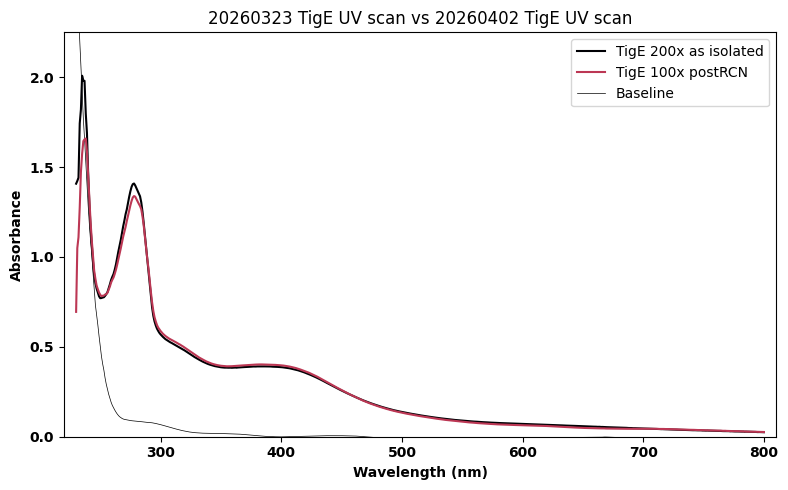

Stats for TigE 200x as isolated:
A280: 1.38
A400: 0.39
ratio: 3.570
Stats for TigE 100x postRCN:
A280: 1.32
A400: 0.40
ratio: 3.333


In [54]:

# A280 for normalization (and A400 for stats later)
a280_id = (uv_scan_df.iloc[:, 0] - 280).abs().idxmin()
a400_id = (uv_scan_df.iloc[:, 0] - 400).abs().idxmin()
# if normalize_A280:
#     for enz_col in uv_scan_df.columns[2:]:
#         uv_scan_df[enz_col] = uv_scan_df[enz_col] * uv_scan_df.loc[a280_id, normalize_to] / uv_scan_df.loc[a280_id, enz_col]

# set x and y 
x = uv_scan_df.iloc[:, 0]  # wavelengths for x axis 
y_base = uv_scan_df.iloc[:, 1]  # baseline for first y 

# set axes 
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Absorbance", color=color_base)
ax.set_ylim(0, abs_max)
ax.set_xlim([220, 810])

# plot baseline 
ax.plot(x, y_base, color=color_base, linewidth=0.5, label=label_map.get(uv_scan_df.columns[1], uv_scan_df.columns[1]))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5)) # major ticks on multiples of MultipleLocator(x)
ax.tick_params(axis="y", colors=color_base)

# plot enzyme(s) of interest
n_enz = len(uv_scan_df.columns) - 2  # number of enzyme columns
for i, col in enumerate(uv_scan_df.columns[2:]):
    color = cmap(i / max(n_enz, 1))  # normalize index
    ax.plot(x,
            uv_scan_df[col] * uv_scan_df.loc[a280_id, normalize_to] / uv_scan_df.loc[a280_id, col] if normalize_A280 else uv_scan_df[col],
            color=color, 
            label=label_map.get(col, col) + (", normalized" if normalize_A280 and col != normalize_to else "")
            )

# title should match csv files for consistency 
plt.title(" vs ".join(file[:-4] for file in csvfiles) + (" normalized" if normalize_A280 else ""))

# ax.grid(True, axis="x", alpha=0.3)  # gridlines 
fig.tight_layout()

# reorder legend 
handles, labels = plt.gca().get_legend_handles_labels()
order = [*range(1, len(handles)), 0]
plt.legend([handles[label] for label in order],
           [labels[label] for label in order], 
           prop={'weight': 'normal'})

# finished product 
# save png file, png name matches csv and title 
out_png = DATA_DIR / str(" vs ".join(file[:-4] for file in csvfiles) + (" normalized" if normalize_A280 else ""))
fig.savefig(out_png, dpi=1500)
plt.show()

# print A280, A400, and A280/400 ratio per enzyme
for enz_col in uv_scan_df.columns[2:]:
     print(f"Stats for {label_map.get(enz_col, enz_col)}:")
     a280 = uv_scan_df.loc[a280_id, enz_col]
     a400 = uv_scan_df.loc[a400_id, enz_col]
     ratio = a280 / a400
     print(f"A280: {a280:.2f}")
     print(f"A400: {a400:.2f}")
     print(f"ratio: {ratio:.3f}")